In [10]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.kaggle_user_agent_graph import build_graph 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:

llm = "gpt-4o"
provider = "azure"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = "kaggle" 

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


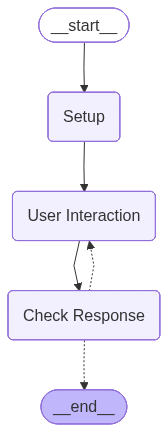

In [12]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [13]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Which states have the highest total federal revenue in 2017?


/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Which states have the highest total federal revenue in 2017?",
    "schema_linking": ["studentmathscore_finrev_fed_17", "studentmathscore_finrev_fed_key_17"],
    "answer": "No data is available for states with the highest total federal revenue in 2017.",
    "sql": "SELECT k.state, SUM(f.t_fed_rev) AS total_fed_rev\nFROM KAGGLE.STUDENTMATHSCORE_FINREV_FED_17 f\nJOIN KAGGLE.STUDENTMATHSCORE_FINREV_FED_KEY_17 k ON f.state_code = k.state_code\nWHERE f.yr_data = 2017\nGROUP BY k.state\nORDER BY total_fed_rev DESC"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Which states have the highest total federal revenue in 2017?",
    "schema_linking": ["studentmathscore_finrev_fed_17", "studentmathscore_finrev_fed_key_17"],
    "answer": "No data is available for states with the highest total federal revenue in 2017.",
    "sql": "SELECT k.state, SUM(f.t_fed_re

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What is the average scale score of students in the states with the highest total federal revenue in 2017 for grade 8 math?",
    "schema_linking": ["STUDENTMATHSCORE_NDECOREEXCEL_MATH_GRADE8", "STUDENTMATHSCORE_FINREV_FED_17"],
    "answer": "No data is available for the average scale score of students in the states with the highest total federal revenue in 2017 for grade 8 math.",
    "sql": "SELECT m.AVERAGE_SCALE_SCORE\nFROM STUDENTMATHSCORE_NDECOREEXCEL_MATH_GRADE8 m\nJOIN STUDENTMATHSCORE_FINREV_FED_17 f\n  ON m.STATE = f.SCHOOL_DISTRICT\nWHERE m.YEAR_ = 2017\n  AND f.YR_DATA = 17\n  AND f.T_FED_REV = (SELECT MAX(T_FED_REV) \n                     FROM STUDENTMATHSCORE_FINREV_FED_17 \n                     WHERE YR_DATA = 17)"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the average scale score of students in the states with the highest 

...

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What awards did 'cobbty01', 'ruthba01', 'wagneho01', 'mathech01', and 'johnswa01' win in their career?",
    "schema_linking": ["kaggle.thehistoryofbaseball_player_award"],
    "answer": "The players 'cobbty01', 'ruthba01', 'wagneho01', 'mathech01', and 'johnswa01' have collectively won 124 awards in their careers. This includes awards like 'Pitching Triple Crown', 'Baseball Magazine All-Star', 'TSN All-Star', and many others across different years and leagues. Let me know if you would like a detailed breakdown of the awards.",
    "sql": "SELECT player_id, award_id, year_, league_id, tie, notes \nFROM kaggle.thehistoryofbaseball_player_award \nWHERE LOWER(player_id) IN (LOWER('cobbty01'), LOWER('ruthba01'), LOWER('wagneho01'), LOWER('mathech01'), LOWER('johnswa01'))"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What awards did 'cobbty01', 'ruthba0

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "What is the highest salary for the players 'cobbty01', 'ruthba01', 'wagneho01', 'mathech01', and 'johnswa01' in their careers?",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_SALARY"],
    "answer": "It seems there is no available data about the highest salaries for the players 'cobbty01', 'ruthba01', 'wagneho01', 'mathech01', and 'johnswa01' in the database.",
    "sql": "SELECT player_id, MAX(salary) AS highest_salary\nFROM KAGGLE.THEHISTORYOFBASEBALL_SALARY\nWHERE LOWER(player_id) IN ('cobbty01', 'ruthba01', 'wagneho01', 'mathech01', 'johnswa01')\nGROUP BY player_id"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "What is the highest salary for the players 'cobbty01', 'ruthba01', 'wagneho01', 'mathech01', and 'johnswa01' in their careers?",
    "schema_linking": ["KAGGLE.THEHISTORYOFBASEBALL_SALARY"],
    "answer": "It seems there is no avail

/home/tomas/PUC/TecGraf/conversational_bm/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
